# 🍷 Machine Learning Homework: Find the Hidden Groups

Welcome to your worksheet on **unsupervised learning**.

In the first Supervised homework you had the answers, each penguin came with its species. Here the situation is different. We have measurements, but **nobody tells
us the groups**. The job of the model is to find the groups on its own. That is **unsupervised**
learning.

We use a small set of data about **wines**. Each wine has 13 chemical measurements. We do not tell
the model anything about the type of wine. We ask it to sort the wines into groups by itself, and
then we check how well it did.

### How to use this worksheet
* Some cells have blank spaces marked `___` and `# TODO`. Fill them in, then run the cell.
* Every task ends with a short footer:
  * ✅ **Check yourself:** what your result should look like.
  * 🔬 **Why it matters:** what this idea is used for in normal life.
  * 🎉 **Fun fact:** how this idea is used in particle physics.
  * 💡 **Go further:** an extra challenge, if you want to push yourself.

You do not need any physics or any earlier machine learning set up to do this (suggested to be done on goole collab).

## Setup
Run this one time. Everything here is already available in Google Colab.

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

print("Setup complete")

Setup complete


## Part 0. Meet the data 🔍  (about 5 min)

We load the wine measurements. Notice that we take only the measurements (`X`). We keep the true
wine types (`y_true`) hidden in a drawer, and we will not show them to the model. We only use them
at the very end, to check the work.


In [50]:
wine = load_wine()
X = wine.data                 # 13 measurements for each wine
y_true = wine.target          # the real wine type: we hide this from the model

# TODO: print the shape of X to see how many wines and how many measurements we have
print("Shape of X:", X.shape)
print("Number of measurements:", len(wine.feature_names))

Shape of X: (178, 13)
Number of measurements: 13


✅ **Check yourself:** you should see **178 wines** and **13 measurements** each.

🔬 **Why it matters:** most data in the real world has no labels. Nobody has gone through and
marked every shopper, every photo, or every collision. Unsupervised learning is how we find
structure when there are no answers to copy.

🎉 **Fun fact:** when particles fly out of a collision, physicists use grouping methods like the
one in this homework to gather them into sprays called jets. Studying jets is how they learn about
quarks and gluons, tiny particles that are never seen on their own.

💡 **Go further:** print `wine.feature_names`. These are real chemical measurements, such as
alcohol and colour intensity. Which ones do you think might separate the wines?


## Part 1. Prepare the data 🧹  (about 5 min)

Clustering measures the distance between wines. If one measurement uses much bigger numbers than
another, it will control all the distances. So, just like with the SVM in the first homework, we
put every measurement on a fair scale first.


In [51]:
# TODO: fit a StandardScaler on X and use it to transform X into X_scaled
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling, first wine:", X[0][:3].round(2))
print("After scaling, first wine: ", X_scaled[0][:3].round(2))

Before scaling, first wine: [14.23  1.71  2.43]
After scaling, first wine:  [ 1.52 -0.56  0.23]


✅ **Check yourself:** after scaling, the numbers should be small and centred around 0
(some negative, some positive), instead of the large raw values.

🔬 **Why it matters:** putting features on a fair scale is one of the most important steps in any
project that measures distance between points. Forgetting it is a very common mistake.

🎉 **Fun fact:** a single particle detector can record hundreds of numbers for one collision, on
many different scales. Physicists must prepare and balance these numbers with great care before
any model can use them.

💡 **Go further:** try the clustering later without scaling and compare. You will usually get worse
groups when the measurements are not balanced.


## Part 2. K means clustering 🎯  (about 7 min)

Now the main idea. **K means** places a number of centre points in the data, then moves them
around until each one sits in the middle of a group of nearby wines. We ask it for 3 groups,
because we believe there are 3 kinds of wine. The model does not know this. It only sees numbers.


In [52]:
# TODO: create a KMeans model that looks for 3 clusters, then fit it on X_scaled
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

clusters = kmeans.labels_     # the group number that the model gave to each wine
print("First 20 group labels:", clusters[:20])
print("Wines in each group:", np.bincount(clusters))
print(kmeans.inertia_)

First 20 group labels: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
Wines in each group: [65 51 62]
1277.928488844643


✅ **Check yourself:** every wine now has a group label of 0, 1 or 2. The three groups should
have roughly **65, 51 and 62** wines in them. The model built these groups without ever seeing the
true wine types.

🔬 **Why it matters:** grouping unlabelled data is used everywhere. Shops use it to place customers
into shopping types. Streaming apps use it to group films that feel similar. It is one of the most
common tools in real machine learning.

🎉 **Fun fact:** grouping particles into jets uses the very same idea of gathering nearby points
together. It is one of the most used tools in all of particle physics.

💡 **Go further:** the value `kmeans.inertia_` measures how tight the groups are (smaller is
tighter). Print it. We will use it in the next part.


## Part 3. How many groups? 📐  (about 7 min)

We asked for 3 groups, but what if we did not know the answer? A common trick is to try many
values and look at how tight the groups are. As we add more groups, the tightness score (called
inertia) always drops. We look for the point where it stops dropping quickly. That bend is a good
choice for the number of groups.


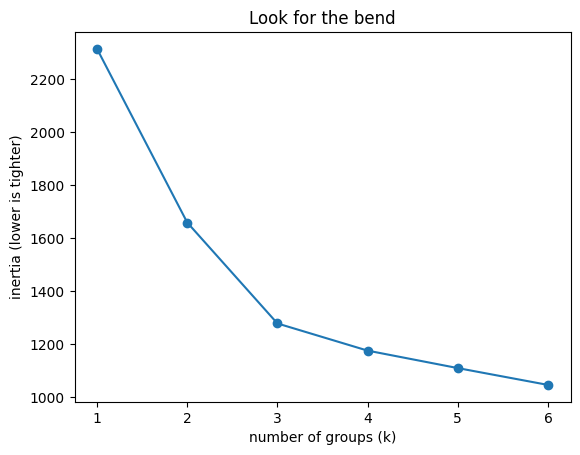

In [53]:
# TODO: for each k from 1 to 6, fit KMeans and store its inertia (tightness score)
inertias = []
for k in range(1, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(model.inertia_)

plt.plot(range(1, 7), inertias, marker="o")
plt.xlabel("number of groups (k)"); plt.ylabel("inertia (lower is tighter)")
plt.title("Look for the bend"); plt.show()

✅ **Check yourself:** the line should fall fast from 1 to 3 groups, then flatten out. The
clearest bend is at **3 groups**, which matches the real number of wine types. Nice.

🔬 **Why it matters:** in real problems nobody tells you how many groups exist. Simple checks like
this one help you make a sensible choice instead of just guessing.

🎉 **Fun fact:** choosing the right number of groups is a real question in physics too. Pick too
few and you blur different things together. Pick too many and you split one real thing into pieces
that do not mean anything.

💡 **Go further:** the bend is not always sharp. Try the same plot without scaling the data and see
how much harder the bend is to find.


## Part 4. See the groups 👀  (about 7 min)

Our wines have 13 measurements, but we can only draw in 2 dimensions. **PCA** is a method that
squeezes many measurements down into a few, while keeping as much of the shape as possible. We
squeeze 13 numbers into 2 so that we can make a picture of the groups.


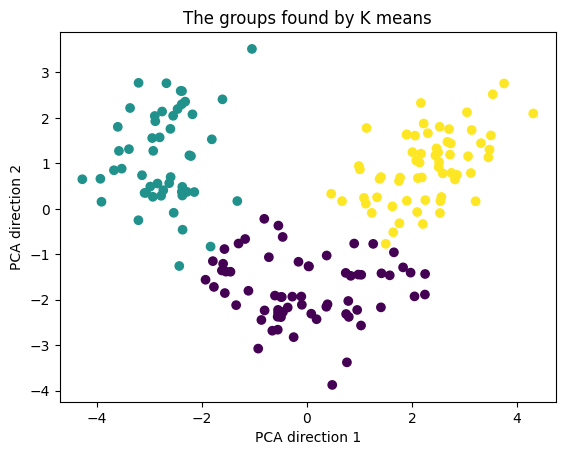

Part of the shape kept by 2 directions: 0.554


In [54]:
# TODO: use PCA to turn the 13 measurements into just 2, so we can plot them
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

#plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, cmap="viridis")
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap="viridis")
plt.xlabel("PCA direction 1"); plt.ylabel("PCA direction 2")
plt.title("The groups found by K means"); plt.show()

print("Part of the shape kept by 2 directions:", round(pca.explained_variance_ratio_.sum(), 3))

✅ **Check yourself:** you should see three fairly separate clouds of points, one colour per
group. The two PCA directions keep about **0.55** (about 55 percent) of the full shape, which is
enough to see clear groups.

🔬 **Why it matters:** humans cannot picture 13 dimensions. Squeezing data down to 2 or 3 so we
can actually look at it is a everyday tool for data scientists.

🎉 **Fun fact:** one collision in a big experiment can have hundreds of numbers. Physicists use
methods like this to squeeze them down to a few important directions that they can plot and
understand.

💡 **Go further:** colour the same plot by the true wine types instead of the clusters
(`c=y_true`). Do the real groups sit in the same places as the ones the model found?


## Part 5. Did we find the real groups? ⚖️  (about 6 min)

Now we open the drawer and take out the true wine types that we hid at the start. Remember, the
model never saw them. Let us check how close the groups it found are to the real ones.


In [55]:
# A table: each row is a group the model found, each column is a true wine type.
table = pd.crosstab(clusters, y_true, rownames=["group found"], colnames=["true type"])
print(table)

# TODO: compute the agreement score between the found groups and the true types.
# adjusted_rand_score gives 1.0 for a perfect match and near 0.0 for random guessing.
score = adjusted_rand_score(y_true, clusters)
print("\nAgreement score (1.0 is perfect):", round(score, 3))

true type     0   1   2
group found            
0             0  65   0
1             0   3  48
2            59   3   0

Agreement score (1.0 is perfect): 0.897


✅ **Check yourself:** in the table, almost every wine of one true type should fall into a
single group (each row has one big number and the rest small). The agreement score should be about
**0.90**, which is very high. The model rediscovered the wine types on its own, using only the
chemical numbers.

🔬 **Why it matters:** this is the surprising power of unsupervised learning. With no answer key at
all, it found groups that closely match the truth. That is how we discover structure in data that
no one has ever labelled.

🎉 **Fun fact:** unsupervised learning helps physicists search for brand new physics. By learning
what normal collisions look like, they can point to the strange ones that do not fit, which might
hold a particle that nobody has discovered yet.

💡 **Go further:** try `KMeans` with 2 groups and with 4 groups, and look at the agreement score
each time. Why does 3 give the best match?


## 🎓 Very well done

You just did a full unsupervised project. You took data with no labels, prepared it, grouped it
with K means, chose a sensible number of groups, drew a picture of the groups with PCA, and
checked your work against the hidden truth.

The big lesson: even with no answer key, machine learning can find real structure in data. This is
one of the most powerful ideas in the whole field, and it is how scientists explore data that has
never been sorted before.

The best way to learn more is to change things and see what happens. Every small experiment turns
a fact that you memorised into an understanding that you own.
